In [ ]:
!pip install fairlearn shap scikit-learn pandas numpy google-cloud-storage matplotlib seaborn 

In [ ]:
!pip3 install --upgrade --quiet  google-cloud-aiplatform




**1. Load and Prepare the Data**





In [ ]:
import pandas as pd
import numpy as np
from google.cloud import storage
import io

# Load data from GCS
from google.cloud import storage
client = storage.Client()
bucket = client.bucket('ml_ops_wk1_826')
blob = bucket.blob('v1/data.csv')
data = blob.download_as_text()

# Read into DataFrame
df = pd.read_csv(io.StringIO(data))

# Add random 'location' attribute (0 or 1)
np.random.seed(42)  # For reproducibility
df['location'] = np.random.randint(0, 2, size=len(df))

print(df.head())
print(f"\nLocation distribution:\n{df['location'].value_counts()}")

**2. Prepare Features and Target**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

# Features and target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'location']]
y = df['species_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Separate sensitive attribute
sensitive_features_train = X_train['location']
sensitive_features_test = X_test['location']

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

**3. Train Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.3f}")

**4.  Fairlearn Implementation**

In [ ]:
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Define metrics
metrics = {
    'accuracy': accuracy_score,
    'precision': lambda y_true, y_pred: precision_score(y_true, y_pred, average='weighted'),
    'recall': lambda y_true, y_pred: recall_score(y_true, y_pred, average='weighted'),
    'selection_rate': selection_rate
}

# Create MetricFrame for test set
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_test,
    sensitive_features=sensitive_features_test
)

print("Overall Metrics:")
print(metric_frame.overall)
print("\nMetrics by Location:")
print(metric_frame.by_group)
print("\nDifference between groups:")
print(metric_frame.difference())

**5. Fairness Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize fairness metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (metric_name, ax) in enumerate(zip(['accuracy', 'precision', 'recall', 'selection_rate'], axes.flatten())):
    metric_by_group = metric_frame.by_group[metric_name]
    metric_by_group.plot(kind='bar', ax=ax, color=['skyblue', 'coral'])
    ax.set_title(f'{metric_name.capitalize()} by Location', fontsize=12)
    ax.set_xlabel('Location')
    ax.set_ylabel(metric_name.capitalize())
    ax.set_xticklabels(['Location 0', 'Location 1'], rotation=0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fairness_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

**6. SHAP Explainability for Virginica Class**

In [17]:
print(f"Type of shap_values: {type(shap_values)}")
print(f"Length of shap_values: {len(shap_values)}")
print(f"Shape of shap_values[2]: {shap_values[2].shape}")
print(f"Length of mean_shap_virginica: {len(mean_shap_virginica)}")
print(f"Length of feature_names: {len(feature_names)}")

Type of shap_values: <class 'numpy.ndarray'>
Length of shap_values: 31
Shape of shap_values[2]: (5, 3)
Length of mean_shap_virginica: 3
Length of feature_names: 5


  0%|          | 0/31 [00:00<?, ?it/s]

Shape of shap_values_virginica: (31, 5)
Length of mean_shap_virginica: 5
Length of feature_names: 5


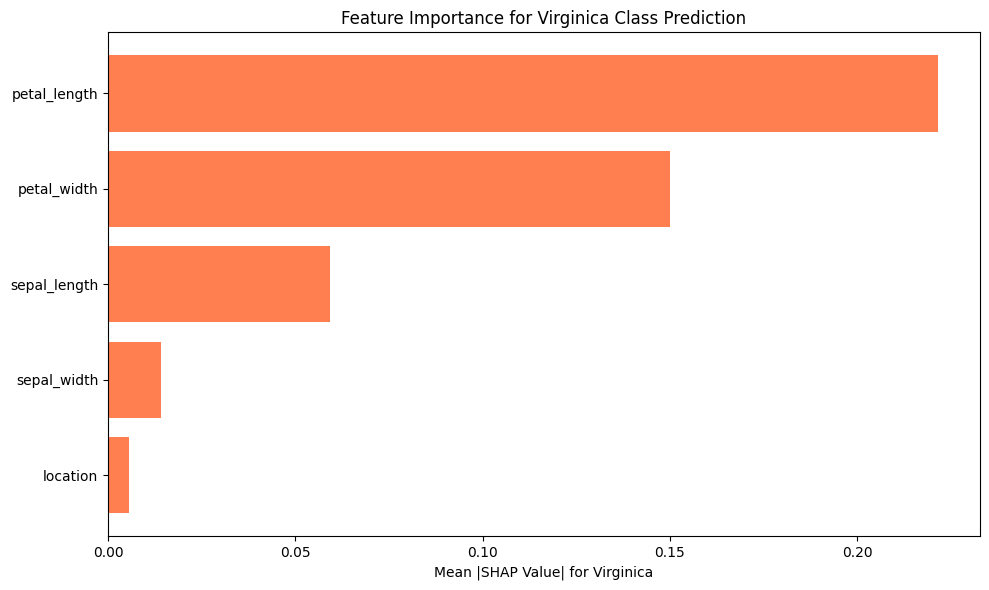


Mean SHAP Values for Virginica:
        Feature  Mean SHAP Value
2  petal_length         0.221714
3   petal_width         0.149924
0  sepal_length         0.059203
1   sepal_width         0.014118
4      location         0.005607


In [18]:
# Mean SHAP Values for Virginica
import shap

# Initialize SHAP explainer
explainer = shap.KernelExplainer(model.predict_proba, X_train)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

# Get feature names
feature_names = X_train.columns.tolist()

# shap_values is (n_samples, n_features, n_classes)
# We need to extract virginica class (class 2) for all samples and features
shap_values_virginica = shap_values[:, :, 2]  # shape: (n_samples, n_features)

# Mean absolute SHAP values for Virginica across all test samples
mean_shap_virginica = np.abs(shap_values_virginica).mean(axis=0)

print(f"Shape of shap_values_virginica: {shap_values_virginica.shape}")
print(f"Length of mean_shap_virginica: {len(mean_shap_virginica)}")
print(f"Length of feature_names: {len(feature_names)}")

# Create bar plot for mean SHAP values
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean SHAP Value': mean_shap_virginica
}).sort_values('Mean SHAP Value', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(shap_df['Feature'], shap_df['Mean SHAP Value'], color='coral')
plt.xlabel('Mean |SHAP Value| for Virginica')
plt.title('Feature Importance for Virginica Class Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('mean_shap_virginica.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMean SHAP Values for Virginica:")
print(shap_df)

**7. Mean SHAP Values for Virginica**

  0%|          | 0/31 [00:00<?, ?it/s]

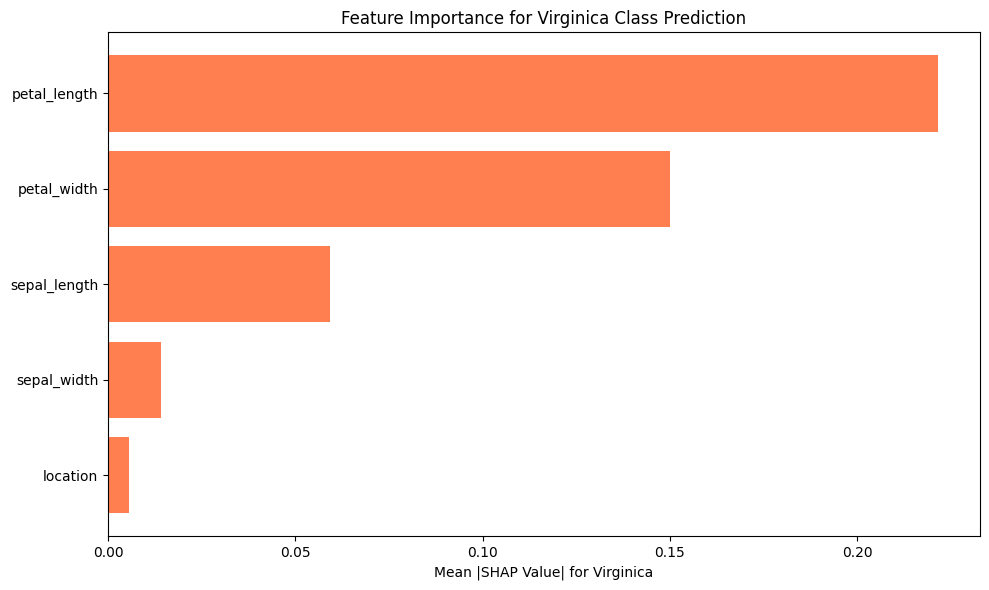


Mean SHAP Values for Virginica:
        Feature  Mean SHAP Value
2  petal_length         0.221714
3   petal_width         0.149924
0  sepal_length         0.059203
1   sepal_width         0.014118
4      location         0.005607


In [21]:
# Mean SHAP Values for Virginica
import shap
import warnings

# Initialize SHAP explainer
explainer = shap.KernelExplainer(model.predict_proba, X_train)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

# Get feature names
feature_names = X_train.columns.tolist()

# shap_values is (n_samples, n_features, n_classes)
# We need to extract virginica class (class 2) for all samples and features
shap_values_virginica = shap_values[:, :, 2]  # shape: (n_samples, n_features)

# Mean absolute SHAP values for Virginica across all test samples
mean_shap_virginica = np.abs(shap_values_virginica).mean(axis=0)

# Create bar plot for mean SHAP values
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean SHAP Value': mean_shap_virginica
}).sort_values('Mean SHAP Value', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(shap_df['Feature'], shap_df['Mean SHAP Value'], color='coral')
plt.xlabel('Mean |SHAP Value| for Virginica')
plt.title('Feature Importance for Virginica Class Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('mean_shap_virginica.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMean SHAP Values for Virginica:")
print(shap_df)

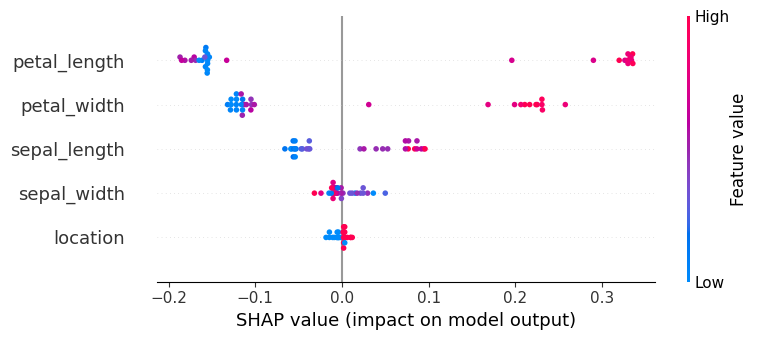

In [22]:
# SHAP Explainability for Virginica Class
shap.initjs()

# Suppress FutureWarning
warnings.filterwarnings('ignore', category=FutureWarning)

# Summary plot for Virginica (class 2)
shap.summary_plot(shap_values[:, :, 2], X_test, feature_names=feature_names)

# Force plot for Virginica - first test instance
shap.force_plot(explainer.expected_value[2], shap_values[0, :, 2], X_test.iloc[0])

# Force plot for Virginica - entire test set
shap.force_plot(explainer.expected_value[2], shap_values[:, :, 2], X_test)